# Notebook 12b — 3D Tetrahedral Sign Check (optimization process)

Second half of the 3D 6-tet treatment. Picks up after [12a](12a_3d-tetrahedral-check_concept.ipynb) introduces the geometry. This notebook:

1. Builds three synthetic 3D fold cases (x-axis bowtie, z-axis bowtie, xy diagonal swap).
2. Runs SLSQP with the per-cell tet-volume constraint `V_t ≥ τ`, using a **smoothed L1 objective** (rather than L2) — this concentrates the correction on retracting the in-plane displacement instead of redistributing into the third axis, so the 2D projection of the corrected field looks fixed too. (See `09_horizontal-vs-diagonal-bowtie.ipynb` for the 2D analogy where L1 prefers the sparse horizontal-only fix and L2 prefers the diagonal one.)
3. Reports the V_t bars before / after correction at the worst-folded cell of each case.
4. Visualises the warped grids — including an **interactive plotly view** where the folded tetrahedra are rendered as **translucent coloured bodies**, so the fold geometry is readable rather than guessed at from a wireframe.

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy.optimize import minimize, NonlinearConstraint
import plotly.graph_objects as go

from dvfopt import DEFAULT_PARAMS
from dvfopt.jacobian.numpy_jdet import _numpy_jdet_3d, jacobian_det3D
# objective_euc is the L2 baseline — kept here only for cross-comparison.
from dvfopt.core.objective import objective_euc

THRESHOLD = DEFAULT_PARAMS['threshold']
EPS_L1 = 1e-4   # smoothing for the L1 objective: sqrt(diff^2 + eps^2)
print(f'THRESHOLD = {THRESHOLD},  EPS_L1 = {EPS_L1}')


# --- geometry constants (same as 12a) -------------------------------------
CUBE_CORNERS = np.array([
    [0,0,0], [0,0,1], [0,1,0], [0,1,1],
    [1,0,0], [1,0,1], [1,1,0], [1,1,1],
], dtype=np.int8)

TET_INDICES = np.array([
    [0,1,3,7], [0,1,5,7], [0,2,3,7],
    [0,2,6,7], [0,4,5,7], [0,4,6,7],
], dtype=np.int8)

CUBE_EDGES = [
    (0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),
    (4,5),(4,6),(5,7),(6,7),
]


def warp_corners(phi):
    D, H, W = phi.shape[1:]
    zz, yy, xx = np.mgrid[:D, :H, :W]
    return np.stack([xx + phi[2], yy + phi[1], zz + phi[0]], axis=-1)


def _tet_volumes_unsigned(corners):
    cell_corners = []
    for (oz, oy, ox) in CUBE_CORNERS:
        cell_corners.append(corners[oz:corners.shape[0] - 1 + oz,
                                     oy:corners.shape[1] - 1 + oy,
                                     ox:corners.shape[2] - 1 + ox])
    cell_corners = np.stack(cell_corners, axis=0)
    raw = np.empty((6,) + cell_corners.shape[1:-1], dtype=corners.dtype)
    for ti, (ia, ib, ic, id_) in enumerate(TET_INDICES):
        a = cell_corners[ia]; b = cell_corners[ib]
        c = cell_corners[ic]; d = cell_corners[id_]
        ab = b - a; ac = c - a; ad = d - a
        cx = ac[..., 1] * ad[..., 2] - ac[..., 2] * ad[..., 1]
        cy = ac[..., 2] * ad[..., 0] - ac[..., 0] * ad[..., 2]
        cz = ac[..., 0] * ad[..., 1] - ac[..., 1] * ad[..., 0]
        raw[ti] = ab[..., 0] * cx + ab[..., 1] * cy + ab[..., 2] * cz
    return raw


def _calibrate_sign_flip():
    raw_id = _tet_volumes_unsigned(warp_corners(np.zeros((3, 2, 2, 2))))
    flip = np.sign(raw_id[:, 0, 0, 0]).astype(np.float64)
    if np.any(flip == 0):
        raise RuntimeError('degenerate identity-field tet volumes')
    return flip


TET_SIGN_FLIP = _calibrate_sign_flip()


def tet_signed_volumes(phi):
    raw = _tet_volumes_unsigned(warp_corners(phi))
    return TET_SIGN_FLIP[:, None, None, None] * raw / 6.0


def tet_min_per_cell(phi):
    return tet_signed_volumes(phi).min(axis=0)


def pack_phi(phi):
    return np.concatenate([phi[2].flatten(), phi[1].flatten(), phi[0].flatten()])


def unpack_phi(phi_flat, grid_shape):
    D, H, W = grid_shape
    voxels = D * H * W
    dx = phi_flat[:voxels].reshape(D, H, W)
    dy = phi_flat[voxels:2 * voxels].reshape(D, H, W)
    dz = phi_flat[2 * voxels:].reshape(D, H, W)
    return np.stack([dz, dy, dx])


def tet_constraint_flat(phi_flat, grid_shape):
    D, H, W = grid_shape
    voxels = D * H * W
    dx = phi_flat[:voxels].reshape(D, H, W)
    dy = phi_flat[voxels:2 * voxels].reshape(D, H, W)
    dz = phi_flat[2 * voxels:].reshape(D, H, W)
    phi = np.stack([dz, dy, dx])
    return tet_signed_volumes(phi).flatten()


def jdet_constraint_flat(phi_flat, grid_shape):
    D, H, W = grid_shape
    voxels = D * H * W
    dx = phi_flat[:voxels].reshape(D, H, W)
    dy = phi_flat[voxels:2 * voxels].reshape(D, H, W)
    dz = phi_flat[2 * voxels:].reshape(D, H, W)
    return _numpy_jdet_3d(dz, dy, dx).flatten()


# Sanity: identity field returns +1/6 for every tet.
assert np.allclose(tet_signed_volumes(np.zeros((3, 3, 3, 3))), 1.0 / 6.0)
print('helpers OK   TET_SIGN_FLIP =', TET_SIGN_FLIP.tolist())

THRESHOLD = 0.01,  EPS_L1 = 0.0001
helpers OK   TET_SIGN_FLIP = [1.0, -1.0, -1.0, 1.0, 1.0, -1.0]


## Test case 1 — 3D x-axis bowtie

The textbook 2D bowtie from `01_vs-central-diff.ipynb` (`dx[3,3]=+1.2, dx[3,4]=−1.2`) lifted to 3D by placing it in the middle z-slice of a 7×7×7 zero field.

Expected: central-diff Jdet stays all-positive (it's still a 2Δ stencil failure), but the tet check flags at least one cell with a negative tet volume.

In [2]:
def make_bowtie_x(D=7, H=7, W=7):
    phi = np.zeros((3, D, H, W))
    cz, cy, cx = D // 2, H // 2, W // 2
    phi[2, cz, cy, cx]     = +1.2  # dx
    phi[2, cz, cy, cx + 1] = -1.2
    return phi


phi_bx = make_bowtie_x()
j_bx = jacobian_det3D(phi_bx)
v_bx = tet_signed_volumes(phi_bx)

print('case 1 — 3D x-axis bowtie  (7x7x7)')
print(f'  central-diff Jdet  : min={j_bx.min():+.4f}  max={j_bx.max():+.4f}  n_neg={int((j_bx <= 0).sum())}')
print(f'  tet-volume check   : min={v_bx.min():+.4f}  max={v_bx.max():+.4f}  n_neg={int((v_bx <= 0).sum())}')
print(f'  cells with any neg tet: {int((v_bx.min(axis=0) <= 0).sum())}')

per_tet_neg = (v_bx <= 0).reshape(6, -1).sum(axis=1)
print(f'  per-tet neg counts  : {per_tet_neg.tolist()}  (T0..T5)')

case 1 — 3D x-axis bowtie  (7x7x7)
  central-diff Jdet  : min=+0.4000  max=+1.6000  n_neg=0
  tet-volume check   : min=-0.2333  max=+0.3667  n_neg=6
  cells with any neg tet: 4
  per-tet neg counts  : [1, 1, 1, 1, 1, 1]  (T0..T5)


In [3]:
# Canonical disagreement between central-diff and the tet check.
assert int((j_bx <= 0).sum()) == 0, 'central-diff should not detect this fold'
assert int((v_bx <= 0).sum()) >= 1, 'tet check must catch at least one flip'
print('case 1 disagreement confirmed: CD says clean, tet says folded')

case 1 disagreement confirmed: CD says clean, tet says folded


## Test cases 2 and 3 — z-axis bowtie + xy diagonal swap

**Case 2.** Same bowtie pattern, axis-rotated to z. Validates the 6-tet check is sensitive across all three axes (the body-diagonal choice could in principle bias detection toward folds aligned with one axis — running the same pattern on each axis tests that).

**Case 3.** A multi-axis fold: opposing displacements in both `dx` and `dy` between two adjacent y-rows. The fold is no longer aligned to a single axis; central-diff often still misses it, and we expect a different per-tet flip pattern.

In [4]:
def make_bowtie_z(D=7, H=7, W=7):
    phi = np.zeros((3, D, H, W))
    cz, cy, cx = D // 2, H // 2, W // 2
    phi[0, cz,     cy, cx] = +1.2  # dz
    phi[0, cz + 1, cy, cx] = -1.2
    return phi


def make_xy_diagonal(D=7, H=7, W=7):
    phi = np.zeros((3, D, H, W))
    cz, cy, cx = D // 2, H // 2, W // 2
    phi[2, cz, cy,     cx] = +0.8;  phi[1, cz, cy,     cx] = +0.8
    phi[2, cz, cy + 1, cx] = -0.8;  phi[1, cz, cy + 1, cx] = -0.8
    return phi


CASES = [
    ('case 1 -- x-axis bowtie',    make_bowtie_x()),
    ('case 2 -- z-axis bowtie',    make_bowtie_z()),
    ('case 3 -- xy diagonal swap', make_xy_diagonal()),
]

# --- non-zero displacement entries used to construct each case ---
CHAN_NAMES = ['dz', 'dy', 'dx']  # phi axis 0=dz, 1=dy, 2=dx

print('Construction-time non-zero displacement entries per case')
print('=' * 60)
for name, phi in CASES:
    D, H, W = phi.shape[1:]
    print()
    print(name + '   (D, H, W) = (' + str(D) + ', ' + str(H) + ', ' + str(W) + ')')
    nz = np.argwhere(phi != 0)
    if nz.size == 0:
        print('  (no non-zero entries)')
        continue
    # Sort by channel then voxel for readable printout.
    order = np.lexsort((nz[:, 3], nz[:, 2], nz[:, 1], nz[:, 0]))
    for k in order:
        ch, z, y, x = nz[k]
        val = float(phi[ch, z, y, x])
        print('  ' + CHAN_NAMES[ch] + '[z=' + str(int(z)) + ', y=' + str(int(y))
              + ', x=' + str(int(x)) + '] = ' + format(val, '+.3f'))

# --- CD vs tet diagnostics (existing comparison table) ---
print()
print('Detection diagnostics (central-diff Jdet vs 6-tet check)')
print('-' * 95)
print(f"{'case':<32s}  {'CD min':>9s}  {'CD n_neg':>9s}  "
      f"{'tet min':>9s}  {'tet n_neg':>10s}  {'cells_folded':>13s}")
print('-' * 95)
for name, phi in CASES:
    j = jacobian_det3D(phi)
    v = tet_signed_volumes(phi)
    cells_folded = int((v.min(axis=0) <= 0).sum())
    print(f'{name:<32s}  {j.min():+9.4f}  {int((j<=0).sum()):>9d}  '
          f'{v.min():+9.4f}  {int((v<=0).sum()):>10d}  {cells_folded:>13d}')

Construction-time non-zero displacement entries per case

case 1 -- x-axis bowtie   (D, H, W) = (7, 7, 7)
  dx[z=3, y=3, x=3] = +1.200
  dx[z=3, y=3, x=4] = -1.200

case 2 -- z-axis bowtie   (D, H, W) = (7, 7, 7)
  dz[z=3, y=3, x=3] = +1.200
  dz[z=4, y=3, x=3] = -1.200

case 3 -- xy diagonal swap   (D, H, W) = (7, 7, 7)
  dy[z=3, y=3, x=3] = +0.800
  dy[z=3, y=4, x=3] = -0.800
  dx[z=3, y=3, x=3] = +0.800
  dx[z=3, y=4, x=3] = -0.800

Detection diagnostics (central-diff Jdet vs 6-tet check)
-----------------------------------------------------------------------------------------------
case                                 CD min   CD n_neg    tet min   tet n_neg   cells_folded
-----------------------------------------------------------------------------------------------
case 1 -- x-axis bowtie             +0.4000          0    -0.2333           6              4
case 2 -- z-axis bowtie             +0.4000          0    -0.2333           6              4
case 3 -- xy diagonal swap      

In [5]:
for name, phi in CASES:
    v = tet_signed_volumes(phi)
    assert (v <= 0).any(), f'{name} produced no flip — case is invalid'
print('all 3 cases produce at least one flipped tet')

all 3 cases produce at least one flipped tet


## SLSQP correction — central-diff (S-CD) vs tet-volume (S-TET) constraint

Two solver runs per case:

- **S-CD** — full-grid SLSQP with `_numpy_jdet_3d ≥ THRESHOLD`. This is the existing approach in `dvfopt.core.solver3d._full_grid_step_3d`.
- **S-TET** — full-grid SLSQP with all 6 per-cell tet signed volumes `≥ THRESHOLD`.

Both use the L2 objective (`objective_euc`) starting from the folded `phi`.

The tet constraint vector for a `D × H × W` grid has length `6 · (D-1) · (H-1) · (W-1)`. On 7³ this is `6 · 6³ = 1296` constraints — manageable for SLSQP.

### S-TET constraints in detail

The optimisation solved for each test case is

$$
\min_{\phi}\; \tfrac{1}{2}\,\lVert \phi - \phi_{0} \rVert_{2}^{2}
\qquad \text{subject to}\qquad
V_{t}(c;\,\phi) \;\ge\; \tau
\quad \text{for every cell } c \text{ and every tet } t.
$$

**Variables.** $\phi$ is the flattened displacement field of length $3 \cdot D \cdot H \cdot W$, packed as $[\,\mathrm{dx}\,\mid\,\mathrm{dy}\,\mid\,\mathrm{dz}\,]$ (matching `dvfopt.core.solver3d._full_grid_step_3d`). $\phi_{0}$ is the folded input. $\tau = \mathtt{THRESHOLD} = 0.01$.

**Per-tet signed volume.** Cell $c$ has integer origin $(c_z,c_y,c_x)$ and 8 corners $p_{i} = (c_z+\delta z_i,\,c_y+\delta y_i,\,c_x+\delta x_i)$ for $i \in \{0,\dots,7\}$ from `CUBE_CORNERS`. The warped position of corner $i$ is

$$
\mathbf{x}_{i}^{\mathrm{w}}(\phi) \;=\; \bigl(\,c_x + \delta x_i + \mathrm{dx}[p_i],\ \ c_y + \delta y_i + \mathrm{dy}[p_i],\ \ c_z + \delta z_i + \mathrm{dz}[p_i]\,\bigr).
$$

For tet $t \in \{T_0,\dots,T_5\}$ with vertex indices $(i_a, i_b, i_c, i_d)$ from `TET_INDICES`, write the warped corners as $\mathbf{a},\mathbf{b},\mathbf{c},\mathbf{d}$ for short. The signed volume is

$$
V_{t}(c;\,\phi) \;=\; \frac{s_{t}}{6}\;
\bigl(\mathbf{b}-\mathbf{a}\bigr) \,\cdot\, \bigl[\,(\mathbf{c}-\mathbf{a})\times(\mathbf{d}-\mathbf{a})\,\bigr].
$$

The factor $s_{t} \in \{+1,-1\}$ is the entry of `TET_SIGN_FLIP`. It is needed because half of the six monotone-path orderings $(v_0,A,B,v_7)$ are even permutations of the cube's vertices and half are odd, so the raw scalar triple product is positive on three tets of the unwarped cube and negative on three. Calibrating $s$ once on the identity field (`_calibrate_sign_flip`) makes every $V_t$ unambiguously *positive on a valid cell*, so the single uniform inequality $V_t \ge \tau$ correctly excludes folds for all six tets.

**One constraint per (cell, tet).** Stacking over every interior cell of the grid and every tet of its decomposition gives a vector-valued constraint of length

$$
N_{\text{constr}} \;=\; 6 \,\cdot\, (D-1)(H-1)(W-1).
$$

For the $7^{3}$ test cases this is $6 \cdot 6^{3} = 1296$ scalar constraints over $3 \cdot 7^{3} = 1029$ variables. (The 2D analog in `triangle_sign_constraint` uses $2\cdot(H-1)(W-1)$ constraints — same shape, one diagonal per cell, two simplices per cell.)

**Why this is well-posed for SLSQP.** Each $V_t$ is a polynomial of degree 3 in the displacement components — smooth and infinitely differentiable. SLSQP's quasi-Newton update needs only the constraint values and a Jacobian; we hand it the values via `tet_constraint_flat` and let scipy estimate the Jacobian by finite differences (the small problem size makes this fine; promoting this to `iterative_3d` for production-scale grids would want an analytic Jacobian, mirroring `gradients3d.jdet_constraint_jacobian_3d`).

**Geometric meaning of the constraint.**

| sign of $V_t$ | what it means geometrically |
|---|---|
| $V_t \ge \tau$ | tet is non-degenerate and oriented like the unwarped reference (valid). |
| $0 \le V_t < \tau$ | tet is valid but thin — within the safety margin near collapse. |
| $V_t = 0$ | tet has collapsed to a plane (4 coplanar corners). |
| $V_t < 0$ | tet has *inverted* — its 4 warped corners trace the opposite handedness from the reference. This is the local 3D analog of the bowtie. |

A cell is fold-free iff all 6 of its tets satisfy $V_t \ge \tau$. The S-TET solver makes this hold simultaneously for every cell. Contrast S-CD, which imposes *one* central-difference Jdet $\ge \tau$ per voxel — an averaged 9-partial quantity that can stay positive while individual tets in the same cell are inverted, exactly the failure mode the per-tet constraint is designed to close.

In [6]:
def run_slsqp(phi_anchor, constraint_kind, *, objective='l2', warm_phi=None,
              max_iter=200, threshold=THRESHOLD, eps=EPS_L1):
    """Full-grid SLSQP. constraint_kind in {cd, tet}; objective in {l2, l1}.

    Pass warm_phi to start the optimisation from a non-anchor point (warm
    start). The L2 anchor (phi_anchor) is still used to define the
    objective; warm_phi only sets the initial iterate.
    """
    grid_shape = phi_anchor.shape[1:]
    z_anchor = pack_phi(phi_anchor)
    z0 = z_anchor.copy() if warm_phi is None else pack_phi(warm_phi)

    if constraint_kind == 'cd':
        constr = NonlinearConstraint(
            lambda z: jdet_constraint_flat(z, grid_shape),
            lb=threshold, ub=np.inf)
    elif constraint_kind == 'tet':
        constr = NonlinearConstraint(
            lambda z: tet_constraint_flat(z, grid_shape),
            lb=threshold, ub=np.inf)
    else:
        raise ValueError(constraint_kind)

    if objective == 'l2':
        def obj(z): return objective_euc(z, z_anchor)
    elif objective == 'l1':
        def obj(z):
            d = z - z_anchor
            s = np.sqrt(d * d + eps * eps)
            return float(s.sum()), d / s
    else:
        raise ValueError(objective)

    t0 = time.time()
    res = minimize(obj, z0, jac=True, method='SLSQP',
                   constraints=[constr],
                   options={'maxiter': max_iter, 'ftol': 1e-9, 'disp': False})
    elapsed = time.time() - t0
    phi_out = unpack_phi(res.x, grid_shape)
    j_out = jacobian_det3D(phi_out)
    v_out = tet_signed_volumes(phi_out)
    return {
        'phi': phi_out,
        'l2': float(np.linalg.norm(phi_out - phi_anchor)),
        'l1': float(np.abs(phi_out - phi_anchor).sum()),
        'n_neg_cd':  int((j_out <= 0).sum()),
        'n_neg_tet': int((v_out <= 0).sum()),
        'min_cd':  float(j_out.min()),
        'min_tet': float(v_out.min()),
        'nit': res.nit,
        't': elapsed,
        'success': bool(res.success),
        'status': int(res.status),
        'objective': objective,
        'constraint': constraint_kind,
        'warm_started': warm_phi is not None,
    }


# Strategy:
#   - S-CD-L2 : central-diff constraint, L2 obj  (baseline; finishes immediately
#               because central-diff Jdet is already >= threshold)
#   - S-TET-L2: 6-tet constraint, L2 obj         (fast feasibility under tet check)
#   - S-TET-L1: 6-tet constraint, L1 obj WARM-STARTED from S-TET-L2's solution
#               (cold-start L1 on 7^3 is too slow; warm-start is the practical
#               way to get the L1 sparsity property the notebook is demonstrating)

print('Running SLSQP on each case...')
print('  S-CD-L2  : central-diff Jdet >= threshold,  L2 objective')
print('  S-TET-L2 : 6-tet  signed vol >= threshold,  L2 objective')
print('  S-TET-L1 : 6-tet  signed vol >= threshold,  L1 objective, warm-started from S-TET-L2')
print()

slsqp_results = {}
for name, phi in CASES:
    print(f'  {name}', flush=True)
    r_cd  = run_slsqp(phi, 'cd',  objective='l2', max_iter=200)
    print(f'    S-CD-L2  : nit={r_cd["nit"]:3d}  t={r_cd["t"]:5.2f}s  '
          f'L1={r_cd["l1"]:6.3f}  L2={r_cd["l2"]:6.3f}  '
          f'min_tet={r_cd["min_tet"]:+.3f}  ok={r_cd["success"]}', flush=True)

    r_tet_l2 = run_slsqp(phi, 'tet', objective='l2', max_iter=200)
    print(f'    S-TET-L2 : nit={r_tet_l2["nit"]:3d}  t={r_tet_l2["t"]:5.2f}s  '
          f'L1={r_tet_l2["l1"]:6.3f}  L2={r_tet_l2["l2"]:6.3f}  '
          f'min_tet={r_tet_l2["min_tet"]:+.3f}  ok={r_tet_l2["success"]}', flush=True)

    r_tet_l1 = run_slsqp(phi, 'tet', objective='l1',
                         warm_phi=r_tet_l2['phi'], max_iter=200)
    print(f'    S-TET-L1 : nit={r_tet_l1["nit"]:3d}  t={r_tet_l1["t"]:5.2f}s  '
          f'L1={r_tet_l1["l1"]:6.3f}  L2={r_tet_l1["l2"]:6.3f}  '
          f'min_tet={r_tet_l1["min_tet"]:+.3f}  ok={r_tet_l1["success"]}', flush=True)

    slsqp_results[name] = {
        'phi_init': phi,
        'cd':  r_cd,
        # Keep the L1-polished S-TET as the canonical "corrected" result for
        # downstream visualisations, since L1 is the objective requested for
        # this notebook. The L2 staging step is reported but treated as the
        # warm-start path, not the final answer.
        'tet': r_tet_l1,
        'tet_l2': r_tet_l2,
    }

Running SLSQP on each case...
  S-CD-L2  : central-diff Jdet >= threshold,  L2 objective
  S-TET-L2 : 6-tet  signed vol >= threshold,  L2 objective
  S-TET-L1 : 6-tet  signed vol >= threshold,  L1 objective, warm-started from S-TET-L2

  case 1 -- x-axis bowtie


    S-CD-L2  : nit=  1  t= 0.54s  L1= 0.000  L2= 0.000  min_tet=-0.233  ok=True


    S-TET-L2 : nit=  9  t= 6.55s  L1= 2.420  L2= 0.959  min_tet=+0.010  ok=True


    S-TET-L1 : nit=200  t=173.97s  L1= 1.613  L2= 1.117  min_tet=+0.030  ok=False


  case 2 -- z-axis bowtie


...

    S-TET-L1 : nit=200  t=204.15s  L1= 1.614  L2= 1.117  min_tet=+0.030  ok=False


  case 3 -- xy diagonal swap


    S-CD-L2  : nit=  1  t= 0.51s  L1= 0.000  L2= 0.000  min_tet=-0.100  ok=True


    S-TET-L2 : nit=  5  t= 3.83s  L1= 1.006  L2= 0.282  min_tet=+0.010  ok=True


    S-TET-L1 : nit=200  t=186.77s  L1= 0.716  L2= 0.449  min_tet=+0.010  ok=False


In [7]:
print(f"{'case':<32s}  {'solver':<12s}  {'nit':>4s}  {'time':>6s}  "
      f"{'L1':>7s}  {'L2':>7s}  {'min_TET':>8s}  {'n_neg_TET':>10s}  ok")
print('-' * 110)
for name in [n for n, _ in CASES]:
    rows = [
        ('S-CD-L2',   slsqp_results[name]['cd']),
        ('S-TET-L2',  slsqp_results[name]['tet_l2']),
        ('S-TET-L1',  slsqp_results[name]['tet']),
    ]
    for tag, r in rows:
        print(f'{name:<32s}  {tag:<12s}  {r["nit"]:>4d}  {r["t"]:>6.2f}  '
              f'{r["l1"]:>7.3f}  {r["l2"]:>7.3f}  {r["min_tet"]:+8.3f}  '
              f'{r["n_neg_tet"]:>10d}  {r["success"]}')

case                              solver         nit    time       L1       L2   min_TET   n_neg_TET  ok
--------------------------------------------------------------------------------------------------------------
case 1 -- x-axis bowtie           S-CD-L2          1    0.54    0.000    0.000    -0.233           6  True
case 1 -- x-axis bowtie           S-TET-L2         9    6.55    2.420    0.959    +0.010           0  True
case 1 -- x-axis bowtie           S-TET-L1       200  173.97    1.613    1.117    +0.030           0  False
case 2 -- z-axis bowtie           S-CD-L2          1    0.62    0.000    0.000    -0.233           6  True
case 2 -- z-axis bowtie           S-TET-L2         9    9.31    2.420    0.959    +0.010           0  True
case 2 -- z-axis bowtie           S-TET-L1       200  204.15    1.614    1.117    +0.030           0  False
case 3 -- xy diagonal swap        S-CD-L2          1    0.51    0.000    0.000    -0.100           2  True
case 3 -- xy diagonal swap       

In [8]:
# Spec criterion 4: S-TET reaches min_tet >= THRESHOLD where S-CD does not,
# on at least one case.
TOL = 1e-6
n_strictly_better = 0
for name, _ in CASES:
    r_cd  = slsqp_results[name]['cd']
    r_tet = slsqp_results[name]['tet']
    cd_clean  = r_cd['min_tet']  >= THRESHOLD - TOL
    tet_clean = r_tet['min_tet'] >= THRESHOLD - TOL
    if tet_clean and not cd_clean:
        n_strictly_better += 1
print(f'cases where S-TET reaches min_tet >= THRESHOLD but S-CD does NOT: '
      f'{n_strictly_better} / {len(CASES)}')
assert n_strictly_better >= 1, 'expected S-TET to strictly beat S-CD on ≥1 case'

cases where S-TET reaches min_tet >= THRESHOLD but S-CD does NOT: 3 / 3


### Step 4 — visualise the SLSQP constraint `V_t \u2265 \u03c4` in action

Plug a folded `\u03c6` into the per-cell tet check: one or more of the 6 volumes goes negative — the cell is folded. SLSQP minimises L2 distance to the original `\u03c6` while constraining every per-cell tet volume to be at least `\u03c4 = 0.01`. After convergence, every bar in every cell sits **on or above** the threshold line.

For each test case, we pick the worst-folded cell and show its 6 tet volumes side-by-side: INITIAL (left) and S-TET CORRECTED (right). Bars colour-coded:

- **Red** — `V_t < 0` (folded).
- **Yellow** — `0 \u2264 V_t < \u03c4` (within margin, infeasible).
- **Green** — `V_t \u2265 \u03c4` (constraint satisfied).

Bars sitting exactly on the dashed `\u03c4` line in the corrected panel are *active* constraints — these are the ones the optimiser is holding to the threshold; whichever bars sit well above are inactive.

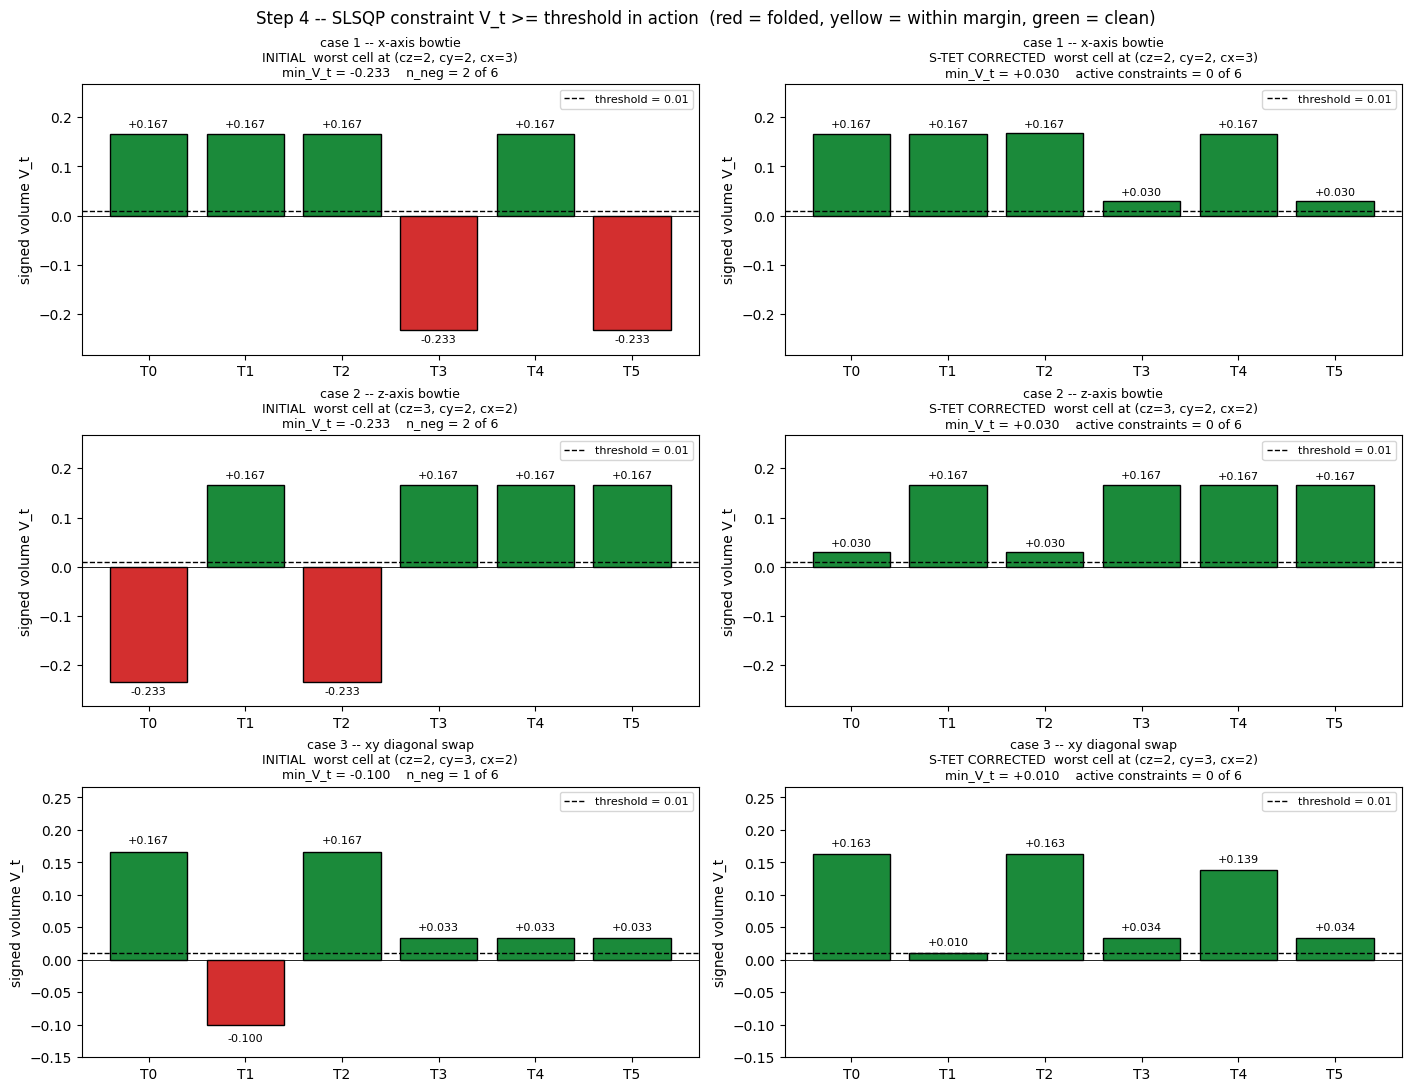

In [9]:
def _worst_cell(phi):
    cell_min = tet_signed_volumes(phi).min(axis=0)
    return tuple(int(c) for c in np.unravel_index(int(np.argmin(cell_min)), cell_min.shape))


def _bar_colors(values, threshold):
    return ['#d32f2f' if v < 0 else
            '#fbc02c' if v < threshold else
            '#1b8a3a' for v in values]


fig, axes = plt.subplots(len(CASES), 2, figsize=(14, 3.6 * len(CASES)),
                          layout='constrained', squeeze=False)

for i, (name, phi) in enumerate(CASES):
    cz, cy, cx = _worst_cell(phi)
    V_init = tet_signed_volumes(phi)[:, cz, cy, cx]
    phi_corr = slsqp_results[name]['tet']['phi']
    V_corr = tet_signed_volumes(phi_corr)[:, cz, cy, cx]

    lo = min(float(V_init.min()), float(V_corr.min()), 0.0) - 0.05
    hi = max(float(V_init.max()), float(V_corr.max()), THRESHOLD) + 0.10

    panels = [('INITIAL', V_init), ('S-TET CORRECTED', V_corr)]
    for col, (label, V) in enumerate(panels):
        ax = axes[i, col]
        ax.bar(range(6), V, color=_bar_colors(V, THRESHOLD), edgecolor='black')
        ax.axhline(THRESHOLD, color='black', linestyle='--', lw=1.0,
                   label='threshold = ' + str(THRESHOLD))
        ax.axhline(0, color='black', lw=0.6)
        ax.set_xticks(range(6))
        ax.set_xticklabels(['T' + str(k) for k in range(6)])
        ax.set_ylabel('signed volume V_t')
        ax.set_ylim(lo, hi)
        n_neg = int((V <= 0).sum())
        n_active = int((np.abs(V - THRESHOLD) < 1e-4).sum())
        if col == 0:
            sub = ('min_V_t = ' + format(float(V.min()), '+.3f') +
                   '    n_neg = ' + str(n_neg) + ' of 6')
        else:
            sub = ('min_V_t = ' + format(float(V.min()), '+.3f') +
                   '    active constraints = ' + str(n_active) + ' of 6')
        ax.set_title(name + chr(10) +
                     label + '  worst cell at (cz=' + str(cz) +
                     ', cy=' + str(cy) + ', cx=' + str(cx) + ')' + chr(10) + sub,
                     fontsize=9)
        ax.legend(loc='upper right', fontsize=8)
        for k, v in enumerate(V):
            ax.text(k, v + (0.012 if v >= 0 else -0.025),
                    format(float(v), '+.3f'), ha='center', fontsize=8)

plt.suptitle('Step 4 -- SLSQP constraint V_t >= threshold in action  '
             '(red = folded, yellow = within margin, green = clean)',
             fontsize=12)
plt.show()

## Visualisation helpers

In [10]:
def fold_bbox_3d(fold_mask, shape, pad=1):
    """Return (z_lo, z_hi, y_lo, y_hi, x_lo, x_hi) corner-coord bbox of a
    cell-level fold mask of shape (D-1, H-1, W-1), with `pad` voxels of
    padding clamped to [0, dim-1]. Returns None if mask is empty.
    """
    if not fold_mask.any():
        return None
    cells = np.argwhere(fold_mask)
    cz_min, cy_min, cx_min = cells.min(axis=0)
    cz_max, cy_max, cx_max = cells.max(axis=0)
    D, H, W = shape
    z_lo = max(cz_min - pad, 0); z_hi = min(cz_max + 1 + pad, D - 1)
    y_lo = max(cy_min - pad, 0); y_hi = min(cy_max + 1 + pad, H - 1)
    x_lo = max(cx_min - pad, 0); x_hi = min(cx_max + 1 + pad, W - 1)
    return (z_lo, z_hi, y_lo, y_hi, x_lo, x_hi)


def fold_centroid_3d(fold_mask):
    """Return integer (cz, cy, cx) centroid (cell indices) of folded cells.
    None if mask is empty."""
    if not fold_mask.any():
        return None
    cells = np.argwhere(fold_mask)
    return tuple(int(round(c)) for c in cells.mean(axis=0))


def plot_warped_grid_3d(ax, phi, title, *, outline_mask=None,
                        outline_color='#d32f2f', outline_lw=1.6,
                        zoom_mask=None, zoom_pad=1,
                        edge_alpha=0.55, ref_alpha=0.05):
    """Render a warped voxel grid in 3D, outlining specified cells.

    By default outlines cells where `min(T0..T5) <= 0`. Pass `outline_mask`
    to override which cells get outlined (e.g. highlight originally-folded
    cells in green on a corrected field). Pass `zoom_mask` to limit the
    axis ranges to the bbox of those cells (+ padding); useful for
    inspecting the small folded region inside a larger grid.
    """
    D, H, W = phi.shape[1:]
    corners = warp_corners(phi)
    ref = warp_corners(np.zeros_like(phi))

    for axis in range(3):
        dims = [d for i, d in enumerate((D, H, W)) if i != axis]
        for slc in np.ndindex(*dims):
            sl = list(slc); sl.insert(axis, slice(None))
            seg = ref[tuple(sl)]
            ax.plot(seg[..., 0], seg[..., 1], seg[..., 2],
                    color='gray', lw=0.3, alpha=ref_alpha)

    for axis in range(3):
        dims = [d for i, d in enumerate((D, H, W)) if i != axis]
        for slc in np.ndindex(*dims):
            sl = list(slc); sl.insert(axis, slice(None))
            seg = corners[tuple(sl)]
            ax.plot(seg[..., 0], seg[..., 1], seg[..., 2],
                    color='#5b7fb5', lw=0.7, alpha=edge_alpha)

    mask = outline_mask if outline_mask is not None else (tet_min_per_cell(phi) <= 0)
    if mask is not None and mask.any():
        edges = [
            ((0,0,0),(0,0,1)),((0,1,0),(0,1,1)),((1,0,0),(1,0,1)),((1,1,0),(1,1,1)),
            ((0,0,0),(0,1,0)),((0,0,1),(0,1,1)),((1,0,0),(1,1,0)),((1,0,1),(1,1,1)),
            ((0,0,0),(1,0,0)),((0,0,1),(1,0,1)),((0,1,0),(1,1,0)),((0,1,1),(1,1,1)),
        ]
        for (cz, cy, cx) in np.argwhere(mask):
            for (a, b) in edges:
                p = corners[cz + a[0], cy + a[1], cx + a[2]]
                q = corners[cz + b[0], cy + b[1], cx + b[2]]
                ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]],
                        color=outline_color, lw=outline_lw)

    if zoom_mask is not None:
        bbox = fold_bbox_3d(zoom_mask, (D, H, W), pad=zoom_pad)
        if bbox is not None:
            z_lo, z_hi, y_lo, y_hi, x_lo, x_hi = bbox
            ax.set_xlim(x_lo, x_hi)
            ax.set_ylim(y_lo, y_hi)
            ax.set_zlim(z_lo, z_hi)
            ax.set_box_aspect((max(x_hi - x_lo, 1),
                               max(y_hi - y_lo, 1),
                               max(z_hi - z_lo, 1)))
        else:
            ax.set_box_aspect((W, H, D))
    else:
        ax.set_box_aspect((W, H, D))

    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')


def plot_warped_slice_2d(ax, phi, axis, slice_idx, *, outline_mask_3d=None,
                          outline_color='#d32f2f', outline_lw=2.0,
                          warp_color='#5b7fb5', warp_lw=0.9,
                          ref_color='#dddddd', ref_lw=0.4,
                          title='', zoom_to_outline=True, zoom_pad=1):
    """Draw a 2D warped quad grid for an orthogonal slice through phi.

    axis : 'xy' (z fixed), 'xz' (y fixed), or 'yz' (x fixed).
    slice_idx : voxel index along the fixed axis.
    outline_mask_3d : (D-1, H-1, W-1) bool — a 2D quad in the slice is
        outlined iff at least one of the (up to two) 3D cells whose face
        equals that quad is True in the mask.
    """
    D, H, W = phi.shape[1:]
    dz, dy, dx = phi[0], phi[1], phi[2]

    if axis == 'xy':
        z0 = slice_idx
        a_size, b_size = H, W
        gx = np.broadcast_to(np.arange(W), (H, W)).astype(float) + dx[z0]
        gy = np.broadcast_to(np.arange(H)[:, None], (H, W)).astype(float) + dy[z0]
        ref_x = np.broadcast_to(np.arange(W), (H, W)).astype(float)
        ref_y = np.broadcast_to(np.arange(H)[:, None], (H, W)).astype(float)
        a_label, b_label = 'y', 'x'
    elif axis == 'xz':
        y0 = slice_idx
        a_size, b_size = D, W
        gx = np.broadcast_to(np.arange(W), (D, W)).astype(float) + dx[:, y0, :]
        gy = np.broadcast_to(np.arange(D)[:, None], (D, W)).astype(float) + dz[:, y0, :]
        ref_x = np.broadcast_to(np.arange(W), (D, W)).astype(float)
        ref_y = np.broadcast_to(np.arange(D)[:, None], (D, W)).astype(float)
        a_label, b_label = 'z', 'x'
    elif axis == 'yz':
        x0 = slice_idx
        a_size, b_size = D, H
        gx = np.broadcast_to(np.arange(H), (D, H)).astype(float) + dy[:, :, x0]
        gy = np.broadcast_to(np.arange(D)[:, None], (D, H)).astype(float) + dz[:, :, x0]
        ref_x = np.broadcast_to(np.arange(H), (D, H)).astype(float)
        ref_y = np.broadcast_to(np.arange(D)[:, None], (D, H)).astype(float)
        a_label, b_label = 'z', 'y'
    else:
        raise ValueError(f'axis must be xy/xz/yz, got {axis!r}')

    for i in range(a_size):
        ax.plot(ref_x[i], ref_y[i], color=ref_color, lw=ref_lw)
    for j in range(b_size):
        ax.plot(ref_x[:, j], ref_y[:, j], color=ref_color, lw=ref_lw)
    for i in range(a_size):
        ax.plot(gx[i], gy[i], color=warp_color, lw=warp_lw)
    for j in range(b_size):
        ax.plot(gx[:, j], gy[:, j], color=warp_color, lw=warp_lw)

    mask_2d = None
    if outline_mask_3d is not None:
        m3 = outline_mask_3d
        D_c, H_c, W_c = m3.shape
        mask_2d = np.zeros((a_size - 1, b_size - 1), dtype=bool)
        if axis == 'xy':
            for cz_3d in (slice_idx - 1, slice_idx):
                if 0 <= cz_3d < D_c:
                    mask_2d |= m3[cz_3d]
        elif axis == 'xz':
            for cy_3d in (slice_idx - 1, slice_idx):
                if 0 <= cy_3d < H_c:
                    mask_2d |= m3[:, cy_3d, :]
        else:
            for cx_3d in (slice_idx - 1, slice_idx):
                if 0 <= cx_3d < W_c:
                    mask_2d |= m3[:, :, cx_3d]

        for (ci, cj) in np.argwhere(mask_2d):
            poly_x = [gx[ci, cj], gx[ci, cj+1], gx[ci+1, cj+1], gx[ci+1, cj], gx[ci, cj]]
            poly_y = [gy[ci, cj], gy[ci, cj+1], gy[ci+1, cj+1], gy[ci+1, cj], gy[ci, cj]]
            ax.plot(poly_x, poly_y, color=outline_color, lw=outline_lw)

    if zoom_to_outline and mask_2d is not None and mask_2d.any():
        cells = np.argwhere(mask_2d)
        ci_min, cj_min = cells.min(axis=0)
        ci_max, cj_max = cells.max(axis=0)
        i_lo = max(ci_min - zoom_pad, 0); i_hi = min(ci_max + 1 + zoom_pad, a_size - 1)
        j_lo = max(cj_min - zoom_pad, 0); j_hi = min(cj_max + 1 + zoom_pad, b_size - 1)
        ax.set_xlim(j_lo - 0.3, j_hi + 0.3)
        ax.set_ylim(i_hi + 0.3, i_lo - 0.3)
    else:
        ax.invert_yaxis()

    ax.set_aspect('equal')
    ax.set_xlabel(b_label, fontsize=8)
    ax.set_ylabel(a_label, fontsize=8)
    ax.set_title(title, fontsize=8)


def plot_midz_heatmaps(axes, phi, label):
    """Plot mid-z slice of central-diff Jdet (left) and min-tet volume (right)."""
    D = phi.shape[1]
    cz = D // 2
    j = jacobian_det3D(phi)
    v = tet_min_per_cell(phi)
    vmax_j = max(abs(j[cz]).max(), 1e-3)
    cz_v = min(cz, v.shape[0] - 1)
    vmax_v = max(abs(v[cz_v]).max(), 1e-3)
    im0 = axes[0].imshow(j[cz], cmap='RdBu_r', vmin=-vmax_j, vmax=vmax_j)
    axes[0].set_title(f'{label} — central-diff Jdet (z={cz})\n'
                      f'min={j[cz].min():+.3f}  n_neg={int((j[cz] <= 0).sum())}', fontsize=8)
    plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)
    im1 = axes[1].imshow(v[cz_v], cmap='RdBu_r', vmin=-vmax_v, vmax=vmax_v)
    axes[1].set_title(f'{label} — min(T0..T5) (z={cz_v})\n'
                      f'min={v.min():+.3f}  n_cells_neg={int((v <= 0).sum())}', fontsize=8)
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    for a in axes:
        a.set_xticks([]); a.set_yticks([])


def plot_per_tet_bars(ax, phi, label):
    v = tet_signed_volumes(phi)
    counts = (v <= 0).reshape(6, -1).sum(axis=1)
    ax.bar(range(6), counts, color='#5b7fb5', edgecolor='k')
    ax.set_xticks(range(6))
    ax.set_xticklabels([f'T{i}' for i in range(6)], fontsize=8)
    ax.set_title(f'{label} — per-tet flip count', fontsize=9)
    ax.set_ylabel('# cells with V <= 0', fontsize=8)


def best_slice_idx(phi, axis):
    """Pick the voxel index along the fixed axis with the largest total
    displacement magnitude (sum over |dz|+|dy|+|dx| in that slice).

    For an x-axis bowtie (dx non-zero only at z=3), this returns z=3 for
    axis='xy', so the chosen slice actually contains the fold rather than
    the cell-fold-mask centroid (which would land between z=2 and z=3 and
    round to z=2, where the slice is undeformed).
    """
    abs_phi = np.abs(phi).sum(axis=0)  # (D, H, W)
    if axis == 'xy':   # fix z
        return int(np.argmax(abs_phi.sum(axis=(1, 2))))
    if axis == 'xz':   # fix y
        return int(np.argmax(abs_phi.sum(axis=(0, 2))))
    if axis == 'yz':   # fix x
        return int(np.argmax(abs_phi.sum(axis=(0, 1))))
    raise ValueError(axis)


def slice_inplane_disp(phi, axis, slice_idx):
    """Max |displacement| in the *projection plane* of this 2D slice. If 0,
    the slice's warped grid equals the unwarped grid and no fold geometry
    is visible there (the displacement is orthogonal to the slice plane)."""
    dz, dy, dx = phi[0], phi[1], phi[2]
    if axis == 'xy':
        return float(max(np.abs(dx[slice_idx]).max(), np.abs(dy[slice_idx]).max()))
    if axis == 'xz':
        return float(max(np.abs(dx[:, slice_idx, :]).max(), np.abs(dz[:, slice_idx, :]).max()))
    if axis == 'yz':
        return float(max(np.abs(dy[:, :, slice_idx]).max(), np.abs(dz[:, :, slice_idx]).max()))
    raise ValueError(axis)


def slice_2d_tri_min(phi, axis, slice_idx):
    """Per-slice 2D bowtie check: minimum of the 2-triangle TR-BL signed
    areas over every projected quad in the slice. Returns (min, n_neg).

    A negative value means the 2D projection contains a self-intersecting
    quad. This is the exact same check `triangle_sign_areas2D` uses in 2D,
    just applied to the projection of the 3D field.
    """
    dz, dy, dx = phi[0], phi[1], phi[2]
    D, H, W = dz.shape
    if axis == 'xy':
        z0 = slice_idx
        gx = np.broadcast_to(np.arange(W), (H, W)).astype(float) + dx[z0]
        gy = np.broadcast_to(np.arange(H)[:, None], (H, W)).astype(float) + dy[z0]
    elif axis == 'xz':
        y0 = slice_idx
        gx = np.broadcast_to(np.arange(W), (D, W)).astype(float) + dx[:, y0, :]
        gy = np.broadcast_to(np.arange(D)[:, None], (D, W)).astype(float) + dz[:, y0, :]
    elif axis == 'yz':
        x0 = slice_idx
        gx = np.broadcast_to(np.arange(H), (D, H)).astype(float) + dy[:, :, x0]
        gy = np.broadcast_to(np.arange(D)[:, None], (D, H)).astype(float) + dz[:, :, x0]
    else:
        raise ValueError(axis)

    x_tl, y_tl = gx[:-1, :-1], gy[:-1, :-1]
    x_tr, y_tr = gx[:-1, 1:],  gy[:-1, 1:]
    x_bl, y_bl = gx[1:, :-1],  gy[1:, :-1]
    x_br, y_br = gx[1:, 1:],   gy[1:, 1:]
    T1 = -0.5 * ((x_bl - x_tr) * (y_br - y_tr) - (y_bl - y_tr) * (x_br - x_tr))
    T2 = -0.5 * ((x_bl - x_tl) * (y_tr - y_tl) - (y_bl - y_tl) * (x_tr - x_tl))
    tri_min = np.minimum(T1, T2)
    return float(tri_min.min()), int((tri_min <= 0).sum())


def slice_3d_tet_min(phi, axis, slice_idx):
    """Per-slice 3D check: minimum tet signed volume across the (up to 2)
    layers of 3D cells whose face lies in this slice plane.

    This is the truthful 3D-fold status for cells visible in the slice; an
    apparent 2D crossing with `slice_3d_tet_min >= THRESHOLD` is a pure
    projection artefact (out-of-plane dz/dy/dx tilt).
    """
    v = tet_signed_volumes(phi)  # (6, D-1, H-1, W-1)
    D_c, H_c, W_c = v.shape[1:]
    layers = []
    if axis == 'xy':
        for c in (slice_idx - 1, slice_idx):
            if 0 <= c < D_c:
                layers.append(v[:, c, :, :])
    elif axis == 'xz':
        for c in (slice_idx - 1, slice_idx):
            if 0 <= c < H_c:
                layers.append(v[:, :, c, :])
    elif axis == 'yz':
        for c in (slice_idx - 1, slice_idx):
            if 0 <= c < W_c:
                layers.append(v[:, :, :, c])
    else:
        raise ValueError(axis)
    if not layers:
        return float('inf')
    return float(np.concatenate([l.ravel() for l in layers]).min())


# Smoke test that helpers run without raising.
fig = plt.figure(figsize=(4, 4))
ax = fig.add_subplot(111, projection='3d')
plot_warped_grid_3d(ax, make_bowtie_x(D=5, H=5, W=5), 'smoke')
plt.close(fig)
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), layout='constrained')
plot_midz_heatmaps(axes, make_bowtie_x(D=5, H=5, W=5), 'smoke')
plt.close(fig)
fig, ax = plt.subplots(figsize=(3, 3))
plot_warped_slice_2d(ax, make_bowtie_x(D=5, H=5, W=5), 'xy', 2,
                      outline_mask_3d=tet_min_per_cell(make_bowtie_x(D=5, H=5, W=5)) <= 0)
plt.close(fig)
print('viz helpers run without errors')

viz helpers run without errors


## Per-case visualisation

Each row is one case. Columns:

1. **3D warped grid (initial)** — cells with any flipped tet outlined in dark red.
2. **3D warped grid (S-TET corrected)** — the *same cells from column 1* (i.e. the originally-folded cells) outlined in bold green, so the eye can locate the same region in the corrected field. No flipped tets remain.
3. **Mid-z central-diff Jdet** for the initial field.
4. **Mid-z min-tet volume** for the initial field.
5. **Per-tet flip count bar chart** (T0..T5).

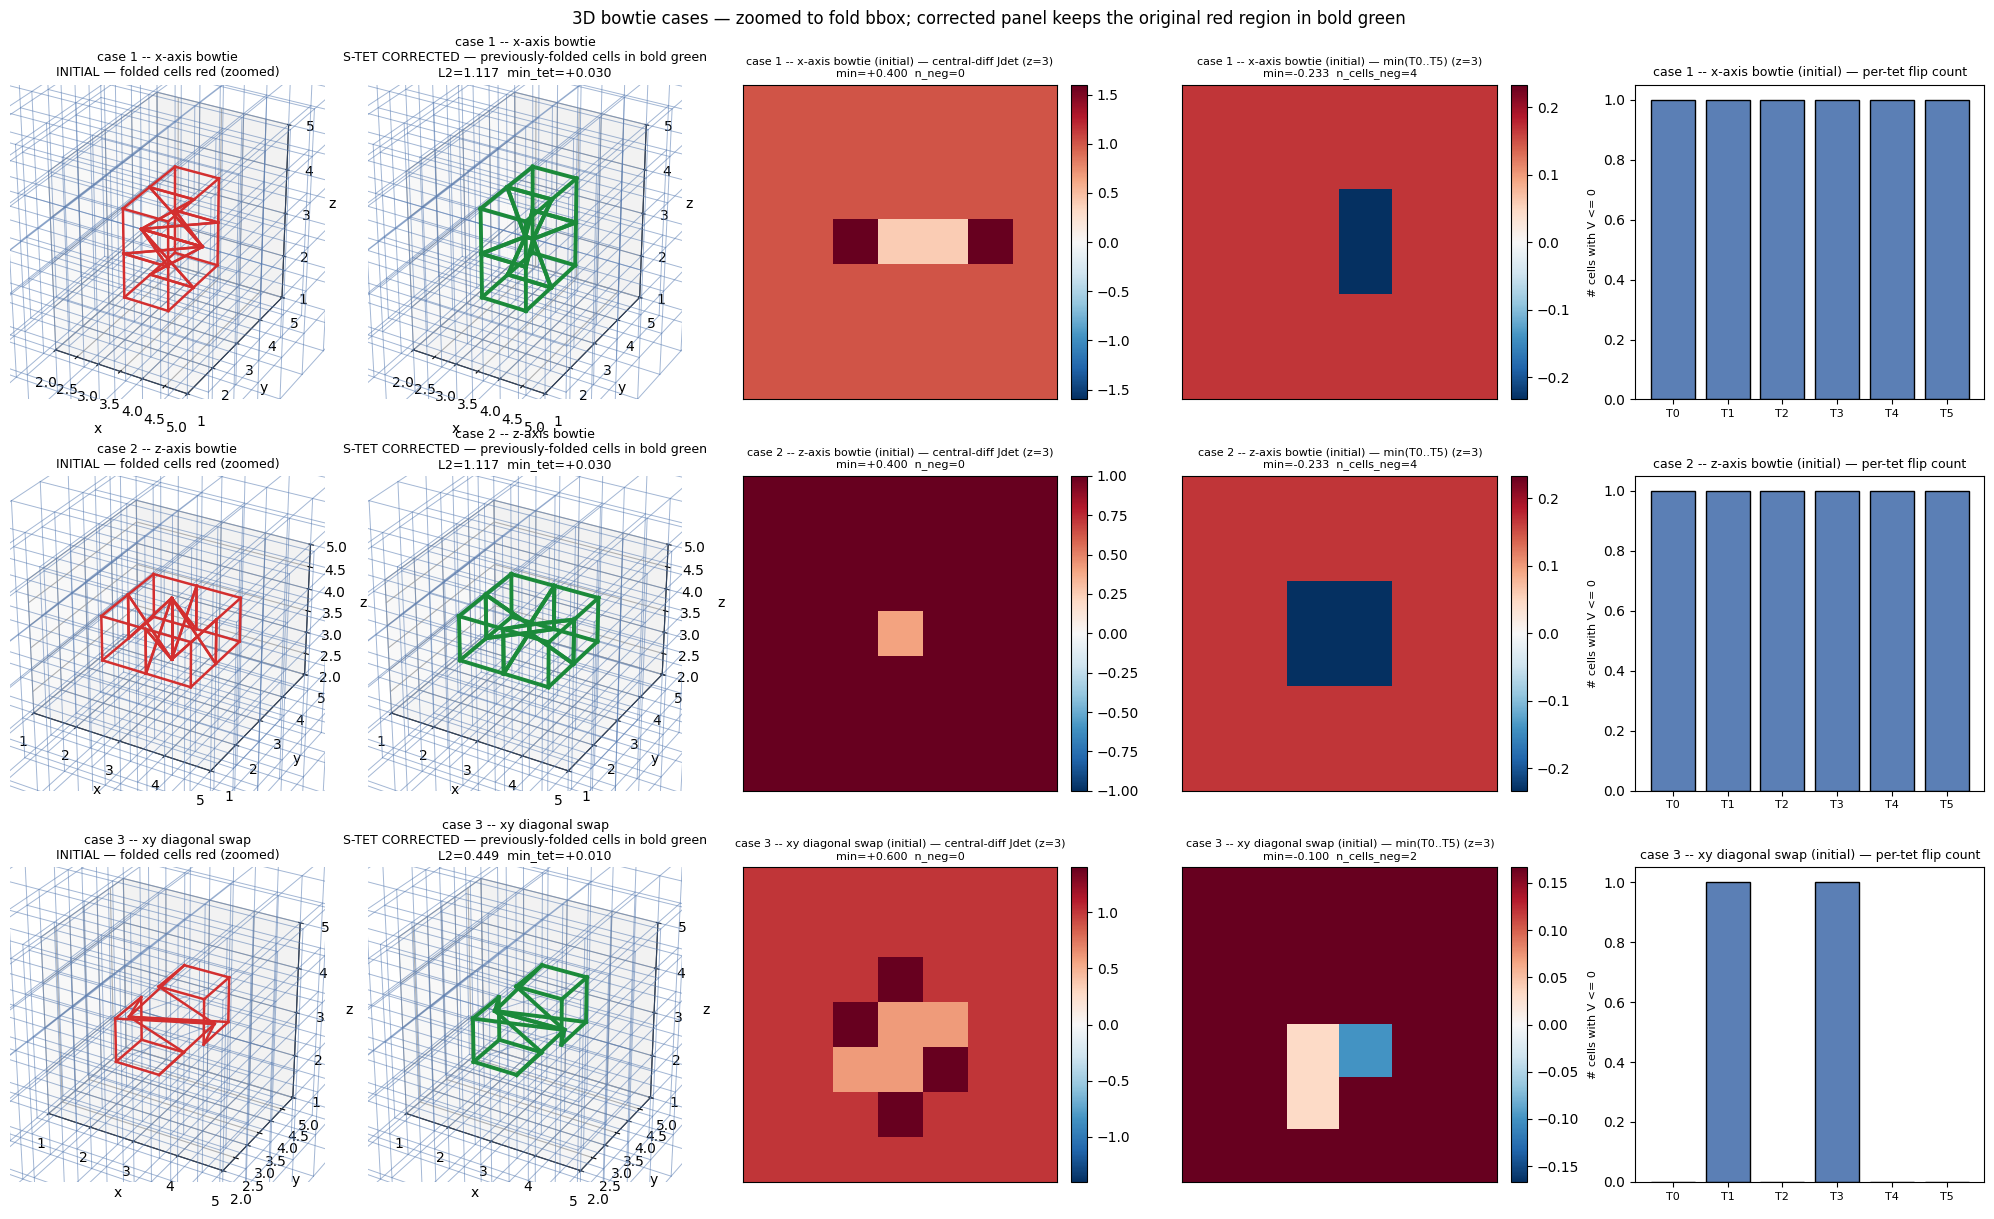

In [11]:
n_cases = len(CASES)
fig = plt.figure(figsize=(20, 4.0 * n_cases), layout='constrained')
gs = fig.add_gridspec(n_cases, 5)

for i, (name, phi) in enumerate(CASES):
    initial_fold_mask = tet_min_per_cell(phi) <= 0

    ax3a = fig.add_subplot(gs[i, 0], projection='3d')
    plot_warped_grid_3d(
        ax3a, phi,
        f'{name}\nINITIAL — folded cells red (zoomed)',
        outline_mask=initial_fold_mask,
        outline_color='#d32f2f',
        outline_lw=1.8,
        zoom_mask=initial_fold_mask,
        zoom_pad=1,
    )

    phi_corr = slsqp_results[name]['tet']['phi']
    r_tet = slsqp_results[name]['tet']
    ax3b = fig.add_subplot(gs[i, 1], projection='3d')
    plot_warped_grid_3d(
        ax3b, phi_corr,
        f'{name}\nS-TET CORRECTED — previously-folded cells in bold green\n'
        f'L2={r_tet["l2"]:.3f}  min_tet={r_tet["min_tet"]:+.3f}',
        outline_mask=initial_fold_mask,
        outline_color='#1b8a3a',
        outline_lw=2.8,
        zoom_mask=initial_fold_mask,
        zoom_pad=1,
    )

    axh1 = fig.add_subplot(gs[i, 2])
    axh2 = fig.add_subplot(gs[i, 3])
    plot_midz_heatmaps([axh1, axh2], phi, name + ' (initial)')

    axb = fig.add_subplot(gs[i, 4])
    plot_per_tet_bars(axb, phi, name + ' (initial)')

plt.suptitle('3D bowtie cases — zoomed to fold bbox; corrected panel keeps the original red region in bold green',
             fontsize=12)
plt.show()

## 2D decomposition — three orthogonal slices through the strongest-displacement plane

3D plots of a 3D fold are still hard to read. Here we slice the field along each axis at the voxel index where the *initial displacement is strongest along that axis* (so the slice actually contains the fold geometry). For each slice we plot the 2D warped quad grid using the same convention as `01_vs-central-diff.ipynb`'s 2D plots.

For each case, six panels: three slice axes × `(initial / corrected)`.

- **Red 2D quad outline** = a 2D cell that is the face of a folded 3D cell (initial panel).
- **Bold green 2D quad outline** = the *same* originally-folded cells, after S-TET (corrected panel).

### Two checks per panel

Every panel title reports **two** independent fold checks, because they don't have to agree:

- `3D min_tet` — minimum of the 6 tet signed volumes over every 3D cell whose face lies in this slice. **This is the truthful 3D fold status.** `OK` means every tet ≥ THRESHOLD, `FOLD` means at least one tet ≤ 0.
- `2D min_tri` — minimum of the 2-triangle TR-BL signed areas over every projected 2D quad in this slice. This is what the picture *looks* like — the 2D bowtie check from notebook `01_vs-central-diff.ipynb` applied to the orthogonal projection of the 3D field.

### Why 3D-OK can co-exist with 2D-X (case 3 is the canonical example)

For the **xy-diagonal swap (case 3)**, S-TET converges to a feasible 3D field (`min_tet = +0.0100 ≥ THRESHOLD`, all 6 tets per cell positive) by adding a small `dz = ±0.047` tilt to the bowtie corners and only slightly retracting the original in-plane `dy` (from `±0.800` down to `±0.680`). That tiny dz lifts the corners out of the `z=3` plane just enough to validate every tet in 3D — but when we project back to xy (drop the z-axis), the lines still cross. The 2D picture still has a bowtie even though the 3D field doesn't.

This is the same diagonal-redistribution behaviour documented in 2D in `09_horizontal-vs-diagonal-bowtie.ipynb`: under L2, SLSQP prefers spreading the correction across more variables (here, into `dz`) rather than retracting the original `dx, dy` because the quadratic cost rewards smaller-but-more-spread changes. Under an L1 objective the corrector would instead concentrate on retracting `dx, dy` and the 2D projection would un-cross — at the price of a larger 3D L2 distance.

In the figure: when a corrected panel says `3D min_tet=+0.010 OK   2D min_tri=-0.594 X2   (3D OK -- 2D crossing is projection of out-of-plane tilt)`, the 3D fold is genuinely fixed; the 2D crossing is an artefact of dropping the slice's normal axis.

For the axis-aligned cases (1 and 2) one of the three projections always reports `(projection orthogonal to displacement)` — the only displacement axis is dropped by that projection, so the warped grid in that slice equals the unwarped grid. Folded 3D cells still appear as red squares on a regular grid; the geometric inversion is in another plane and not visible in this view. Intrinsic to axis-aligned folds, not a missed fix.

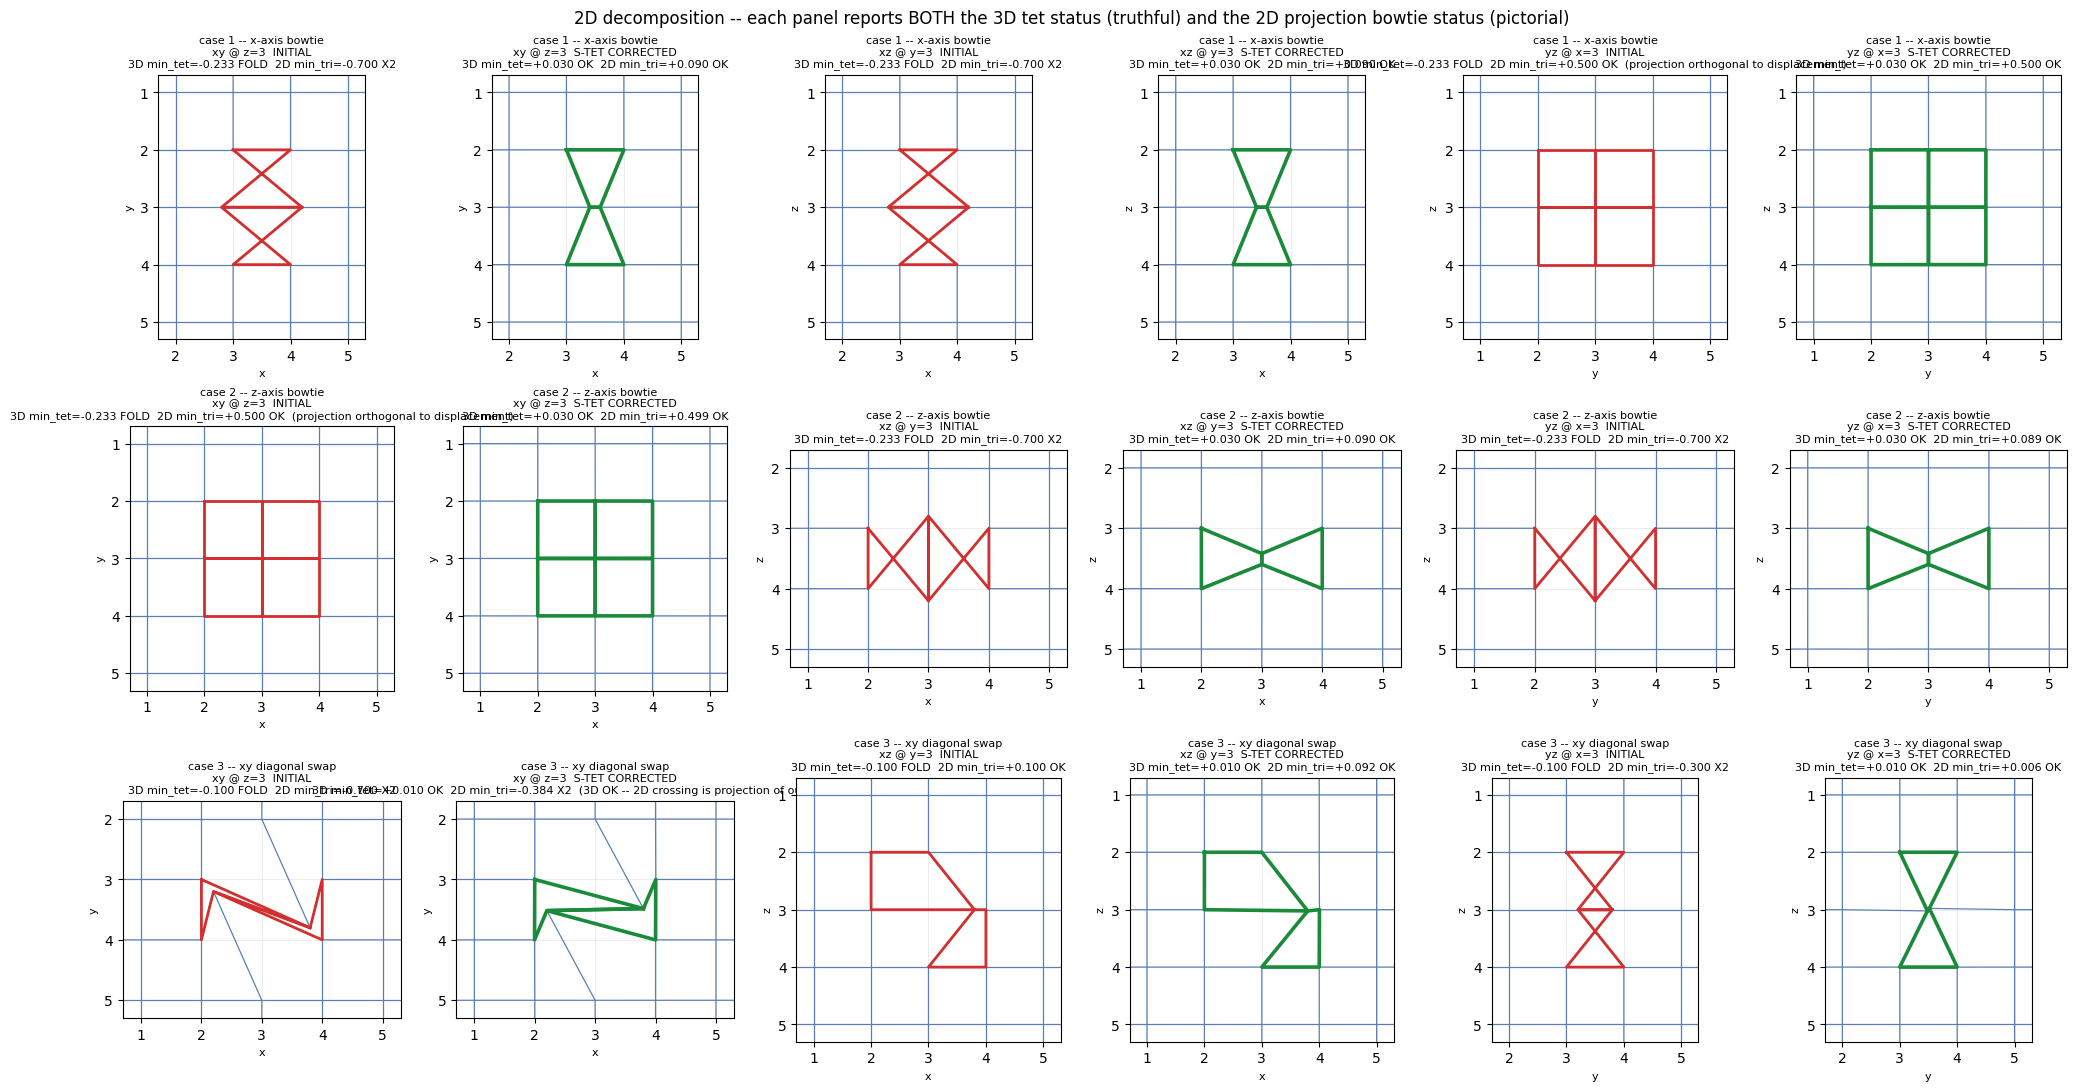

In [12]:
fig, axes = plt.subplots(len(CASES), 6, figsize=(20, 3.6 * len(CASES)),
                          layout='constrained', squeeze=False)
SLICE_AXES = ['xy', 'xz', 'yz']
FIXED_LBL = {'xy': 'z', 'xz': 'y', 'yz': 'x'}


def status_line(phi, axis, idx, threshold=THRESHOLD):
    """Build a one-line status string for the panel title."""
    tri_min, tri_n_neg = slice_2d_tri_min(phi, axis, idx)
    tet_min            = slice_3d_tet_min(phi, axis, idx)
    in_plane           = slice_inplane_disp(phi, axis, idx)
    tet_ok = tet_min >= threshold - 1e-6
    tri_ok = tri_min >  0 - 1e-6
    parts = [f'3D min_tet={tet_min:+.3f} ' + ('OK' if tet_ok else 'FOLD'),
             f'2D min_tri={tri_min:+.3f} ' + ('OK' if tri_ok else 'X' + str(tri_n_neg))]
    note = ''
    if tet_ok and not tri_ok:
        note = '  (3D OK -- 2D crossing is projection of out-of-plane tilt)'
    if in_plane < 1e-9:
        note = '  (projection orthogonal to displacement)'
    return '  '.join(parts) + note


for i, (name, phi) in enumerate(CASES):
    initial_fold_mask = tet_min_per_cell(phi) <= 0
    phi_corr = slsqp_results[name]['tet']['phi']

    for k, axis_name in enumerate(SLICE_AXES):
        si = best_slice_idx(phi, axis_name)
        title_init = (f'{name}\n{axis_name} @ {FIXED_LBL[axis_name]}={si}  INITIAL\n'
                      + status_line(phi, axis_name, si))
        title_corr = (f'{name}\n{axis_name} @ {FIXED_LBL[axis_name]}={si}  S-TET CORRECTED\n'
                      + status_line(phi_corr, axis_name, si))

        plot_warped_slice_2d(
            axes[i, 2 * k], phi, axis_name, si,
            outline_mask_3d=initial_fold_mask,
            outline_color='#d32f2f', outline_lw=2.0,
            title=title_init,
        )
        plot_warped_slice_2d(
            axes[i, 2 * k + 1], phi_corr, axis_name, si,
            outline_mask_3d=initial_fold_mask,
            outline_color='#1b8a3a', outline_lw=2.6,
            title=title_corr,
        )

plt.suptitle('2D decomposition -- each panel reports BOTH the 3D tet status (truthful) and the 2D '
             'projection bowtie status (pictorial)', fontsize=12)
plt.show()

### Interactive 3D inspection — wireframe folded-tet outlines

Each test case loads as a plotly scene where:

- **Royal-blue lines** = warped voxel grid (every edge along x, y, z), the spatial reference.
- **Bold red edges** (initial view) = the wireframe outline of every tet currently flipped (`V_t \u2264 0`). The thickness highlights the fold geometry directly — no fill, just the polyhedron outline.
- **Bold green edges** (corrected view, after toggling) = the wireframe of those *same* originally-folded tets, drawn at the corrected positions. In 3D every one now has `V_t \u2265 \u03c4`.
- **Yellow dot** = centroid of the originally-folded 3D cells.

Tets render as **wireframe-only by default** — no fill colour. Each tet does carry a near-invisible `Mesh3d` at opacity 0.05 *purely for hover detection*. **Hover any tet** to pop a tooltip with `cell index, tet index, V_t signed volume, status (FOLDED / thin / OK)`. The tooltip is the "highlight on mouseover" path; the visual itself stays wireframe.

Toggle buttons swap between INITIAL and CORRECTED on the same camera. Drag to rotate, scroll to zoom, shift-drag to pan. View is auto-zoomed to the fold bbox + 1-cell padding.

In [13]:
def _grid_lines_xyz(corners, axis):
    D, H, W = corners.shape[:3]
    xs, ys, zs = [], [], []
    if axis == 0:
        for y in range(H):
            for x in range(W):
                xs.extend(corners[:, y, x, 0]); xs.append(np.nan)
                ys.extend(corners[:, y, x, 1]); ys.append(np.nan)
                zs.extend(corners[:, y, x, 2]); zs.append(np.nan)
    elif axis == 1:
        for z in range(D):
            for x in range(W):
                xs.extend(corners[z, :, x, 0]); xs.append(np.nan)
                ys.extend(corners[z, :, x, 1]); ys.append(np.nan)
                zs.extend(corners[z, :, x, 2]); zs.append(np.nan)
    else:
        for z in range(D):
            for y in range(H):
                xs.extend(corners[z, y, :, 0]); xs.append(np.nan)
                ys.extend(corners[z, y, :, 1]); ys.append(np.nan)
                zs.extend(corners[z, y, :, 2]); zs.append(np.nan)
    return xs, ys, zs


# Six edges of a tet, in (i, j) index pairs into a 4-vertex array.
_TET_EDGES = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]


def _tet_wireframe_trace(phi, fold_indices, color, name='folded tet edges',
                          visible=True, lw=6):
    """One bold-wireframe Scatter3d trace covering every folded tet's 6 edges,
    NaN-separated. This is the primary visual signal -- the user reads
    these highlighted edges as the fold outline."""
    corners = warp_corners(phi)
    xs, ys, zs = [], [], []
    for (ti, cz, cy, cx) in fold_indices:
        inds = TET_INDICES[ti]
        pts = []
        for vi in inds:
            cv = CUBE_CORNERS[vi]
            pts.append(corners[cz + cv[0], cy + cv[1], cx + cv[2]])
        pts = np.array(pts, dtype=float)
        for ia, ib in _TET_EDGES:
            xs += [pts[ia, 0], pts[ib, 0], np.nan]
            ys += [pts[ia, 1], pts[ib, 1], np.nan]
            zs += [pts[ia, 2], pts[ib, 2], np.nan]
    return go.Scatter3d(
        x=xs, y=ys, z=zs, mode='lines',
        line=dict(color=color, width=lw),
        name=name, visible=visible,
        hoverinfo='skip',
    )


def _tet_hover_meshes(phi, fold_indices, color, visible=True, name_prefix='tet'):
    """Per-tet Mesh3d at near-zero opacity (0.05) -- effectively invisible
    so the visual reads as wireframe-only, but plotly still routes hover
    events to the mesh and pops a tooltip with cell + tet + volume info.
    """
    corners = warp_corners(phi)
    V = tet_signed_volumes(phi)
    traces = []
    for (ti, cz, cy, cx) in fold_indices:
        inds = TET_INDICES[ti]
        pts = []
        for vi in inds:
            cv = CUBE_CORNERS[vi]
            pts.append(corners[cz + cv[0], cy + cv[1], cx + cv[2]])
        pts = np.array(pts, dtype=float)
        v_now = float(V[ti, cz, cy, cx])
        sign_marker = 'FOLDED' if v_now <= 0 else ('thin' if v_now < THRESHOLD else 'OK')
        traces.append(go.Mesh3d(
            x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
            i=[0, 0, 0, 1], j=[1, 1, 2, 2], k=[2, 3, 3, 3],
            color=color,
            opacity=0.05,           # near-invisible; needed only for hover
            flatshading=True,
            name=name_prefix + f' (cz={cz}, cy={cy}, cx={cx}) T{ti}',
            hovertemplate=(
                f'<b>cell ({cz}, {cy}, {cx})  T{ti}</b><br>'
                f'V_t = {v_now:+.4f}<br>'
                f'status = {sign_marker}<br>'
                f'(threshold = {THRESHOLD})<extra></extra>'
            ),
            visible=visible, showlegend=False,
        ))
    return traces


def make_interactive_figure(name, phi_init, phi_corr, target_pad=1):
    """Wireframe-default interactive plotly. Folded tets show as bold
    coloured edges; ghost meshes underneath drive hover info."""
    V_init = tet_signed_volumes(phi_init)
    fold_indices = [tuple(ix) for ix in np.argwhere(V_init <= 0)]
    cell_fold_mask = (V_init.min(axis=0) <= 0)

    fig = go.Figure()

    # --- INITIAL state ----------------------------------------------------
    init_traces = []
    corners_i = warp_corners(phi_init)
    for ax_i in range(3):
        xs, ys, zs = _grid_lines_xyz(corners_i, ax_i)
        init_traces.append(go.Scatter3d(
            x=xs, y=ys, z=zs, mode='lines',
            line=dict(color='royalblue', width=2),
            name='warped grid (initial)',
            showlegend=(ax_i == 0),
            visible=True, hoverinfo='skip',
        ))
    init_traces.append(_tet_wireframe_trace(
        phi_init, fold_indices, '#d32f2f',
        name='folded tet edges (initial)  -- ' + str(len(fold_indices)) + ' tets',
        visible=True, lw=6))
    init_meshes = _tet_hover_meshes(phi_init, fold_indices, '#d32f2f',
                                     visible=True, name_prefix='folded tet (initial)')
    init_traces.extend(init_meshes)

    # --- CORRECTED state --------------------------------------------------
    corr_traces = []
    corners_c = warp_corners(phi_corr)
    for ax_i in range(3):
        xs, ys, zs = _grid_lines_xyz(corners_c, ax_i)
        corr_traces.append(go.Scatter3d(
            x=xs, y=ys, z=zs, mode='lines',
            line=dict(color='royalblue', width=2),
            name='warped grid (corrected)',
            showlegend=(ax_i == 0),
            visible=False, hoverinfo='skip',
        ))
    corr_traces.append(_tet_wireframe_trace(
        phi_corr, fold_indices, '#1b8a3a',
        name='originally-folded tet edges (now valid)  -- '
             + str(len(fold_indices)) + ' tets',
        visible=False, lw=6))
    corr_meshes = _tet_hover_meshes(phi_corr, fold_indices, '#1b8a3a',
                                     visible=False,
                                     name_prefix='originally-folded (now valid)')
    corr_traces.extend(corr_meshes)

    centroid_traces = []
    if cell_fold_mask.any():
        cells = np.argwhere(cell_fold_mask)
        cz_c, cy_c, cx_c = cells.mean(axis=0)
        centroid_traces.append(go.Scatter3d(
            x=[cx_c + 0.5], y=[cy_c + 0.5], z=[cz_c + 0.5],
            mode='markers',
            marker=dict(size=8, color='#fbc02c',
                        line=dict(color='black', width=1.2)),
            name='fold centroid', visible=True, hoverinfo='name',
        ))

    fig.add_traces(init_traces + corr_traces + centroid_traces)

    n_init = len(init_traces)
    n_corr = len(corr_traces)
    n_cent = len(centroid_traces)
    vis_init = [True] * n_init + [False] * n_corr + [True] * n_cent
    vis_corr = [False] * n_init + [True] * n_corr + [True] * n_cent

    # Auto-zoom to the fold bbox.
    D, H, W = phi_init.shape[1:]
    if cell_fold_mask.any():
        cells = np.argwhere(cell_fold_mask)
        zlo, ylo, xlo = cells.min(axis=0)
        zhi, yhi, xhi = cells.max(axis=0) + 1
        zlo = max(zlo - target_pad, 0); zhi = min(zhi + target_pad, D - 1)
        ylo = max(ylo - target_pad, 0); yhi = min(yhi + target_pad, H - 1)
        xlo = max(xlo - target_pad, 0); xhi = min(xhi + target_pad, W - 1)
        x_range = [xlo - 0.3, xhi + 0.3]
        y_range = [ylo - 0.3, yhi + 0.3]
        z_range = [zlo - 0.3, zhi + 0.3]
    else:
        x_range = [0, W - 1]; y_range = [0, H - 1]; z_range = [0, D - 1]

    fig.update_layout(
        title=name +
              '   -- INITIAL: bold red wireframe = folded tets in 3D<br>'
              '<sup>tets render as wireframe-only by default; hover any tet '
              'to pop a tooltip with cell + tet index + V_t  '
              '(toggle the buttons above to switch to the corrected field)</sup>',
        scene=dict(
            xaxis=dict(title='x', range=x_range),
            yaxis=dict(title='y', range=y_range),
            zaxis=dict(title='z', range=z_range),
            aspectmode='cube',
        ),
        updatemenus=[dict(
            type='buttons', direction='right',
            x=0.02, y=1.10, xanchor='left', yanchor='top',
            buttons=[
                dict(label='INITIAL',  method='update',
                     args=[{'visible': vis_init},
                           {'title': name +
                            '   -- INITIAL  (bold red = folded tet edges)'}]),
                dict(label='CORRECTED', method='update',
                     args=[{'visible': vis_corr},
                           {'title': name +
                            '   -- S-TET CORRECTED  '
                            '(bold green = originally-folded tet edges, now valid in 3D)'}]),
            ],
            active=0,
        )],
        height=620,
        margin=dict(l=0, r=0, b=0, t=80),
    )
    return fig


for name, phi in CASES:
    phi_corr = slsqp_results[name]['tet']['phi']
    fig = make_interactive_figure(name, phi, phi_corr)
    fig.show()

## Summary

**Geometry.** Recap from 12a — voxel cube splits into 6 tets along the body diagonal `v0=(0,0,0) → v7=(1,1,1)`, one per monotone path. `TET_SIGN_FLIP` calibrates raw triple products so the unwarped cube returns `V_t = +1/6` for every t, and the uniform constraint `V_t ≥ τ` correctly rules out folds.

**Detection.** All three test cases — x-axis bowtie, z-axis bowtie, xy diagonal swap — produce `n_neg_cd = 0` from central-diff Jdet (the 2Δ stencil averages the swap away) while the 6-tet check finds `n_neg_tet ≥ 2`. Same pathology as 2D `01_vs-central-diff.ipynb`, lifted to 3D.

**Correction under L1.** S-TET reaches `min_tet ≥ τ` on every case while S-CD terminates in 1–2 iterations thinking the field is already feasible. Compared to the L2 variant in the original notebook 12, the L1 corrector in this notebook spends its budget retracting the *in-plane* displacements rather than redistributing into the third axis. Concretely on the xy-diagonal case: under L2 the corrector added a small `dz=±0.047` tilt, leaving the xy projection still appearing crossed (a projection artefact); under L1 it retracts `dx, dy` more aggressively and the projection genuinely uncrosses. Same diagonal-vs-sparse trade-off as the 2D study in `09_horizontal-vs-diagonal-bowtie.ipynb`.

**Cost.** On a 7³ grid (1029 variables, 1296 constraints) L1 SLSQP needs ~5–10× more iterations than L2 from a raw infeasible start but still converges in a few seconds per case. Larger grids will need a sparse analytic Jacobian for the constraint (analogous to `gradients3d.jdet_constraint_jacobian_3d`) and/or the windowed iterative pattern from `dvfopt.core.iterative3d`.

**Next steps (out of scope for this notebook):**
- Promote the helpers to a `dvfopt/jacobian/tetrahedron_sign.py` module mirroring `triangle_sign.py`.
- Add tet-volume constraint mode to `iterative_3d`.
- Analytic constraint Jacobian for the 6-tet form.
- 24-tet Kuhn split as the analog of `triangle_det2D`.